In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose `sp500_monthly (1).csv` in the dialog

# Get the actual uploaded filename (key of the dict)
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename)

# Basic checks
print(df.columns)
df.head()

Saving sp500_monthly (1).csv to sp500_monthly (1).csv
Loaded file: sp500_monthly (1).csv
Index(['Unnamed: 0', 'date', 'permno', 'comnam', 'ncusip', 'shrcd', 'exchcd',
       'hsiccd', 'ticker', 'gvkey', 'iid', 'start', 'ending', 'ret', 'prc',
       'shrout', 'vol', 'cfacpr', 'cfacshr'],
      dtype='object')


/tmp/ipykernel_19085/2570245787.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


,Unnamed: 0,date,permno,comnam,ncusip,shrcd,exchcd,hsiccd,ticker,gvkey,iid,start,ending,ret,prc,shrout,vol,cfacpr,cfacshr
0,1,2000-01-31,24010,ENTERGY CORP NEW,29364G10,11,1,4911,ETR,7366,1,1957-03-01,2024-12-31,-0.031553,24.9375,241283.0,190694.0,2.000000,2.0
1,3,2000-01-31,12749,K MART CORP,48258410,11,1,5331,KM,6307,1,1957-03-01,2002-01-16,-0.173913,8.3125,493698.0,874803.0,1.000000,1.0
2,5,2000-01-31,23819,HALLIBURTON CO,40621610,11,1,1389,HAL,5439,1,1957-03-01,2024-12-31,-0.102484,36.1250,441754.0,710393.0,2.000000,2.0
3,6,2000-01-31,25769,KERR MCGEE CORP,49238610,11,1,1311,KMG,6403,1,1984-10-04,2006-08-10,-0.108871,55.2500,86466.0,109249.0,2.176876,2.0
4,8,2000-01-31,13688,P G & E CORP,69331C10,11,1,4931,PCG,8264,1,1925-12-31,2019-01-17,0.070122,21.9375,383980.0,258969.0,1.000000,1.0


In [22]:
# Parse dates and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'permno']).copy()

# Standard CRSP-style filters
if 'shrcd' in df.columns:
    df = df[df['shrcd'].isin([10, 11])]
if 'exchcd' in df.columns:
    df = df[df['exchcd'].isin([1, 2, 3])]

# Clean returns
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.dropna(subset=['ret'])

print("Unique dates in filtered data:", df['date'].nunique())
print("Unique permnos in filtered data:", df['permno'].nunique())

# Build raw return panel
ret_panel_full = (
    df.pivot_table(index='date', columns='permno', values='ret', aggfunc='first')
      .sort_index()
)

print("Raw panel shape (T x N):", ret_panel_full.shape)

# -----------------------------
# Dynamic universe parameters
# -----------------------------
MIN_HISTORY = 60       # stock must have at least 60 past monthly returns
K_UNIVERSE = 100       # at each date, keep at most top 100 eligible stocks
MIN_PRICE = 5          # optional price screen, if prc exists

# Optional price panel for screening
if 'prc' in df.columns:
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce')
    prc_panel_full = (
        df.pivot_table(index='date', columns='permno', values='prc', aggfunc='first')
          .sort_index()
          .abs()
    )
else:
    prc_panel_full = None

# Rolling count of available past returns, shifted so only information up to t is used
hist_count = ret_panel_full.notna().rolling(MIN_HISTORY).sum().shift(1)

# Build date-specific eligible universes
eligible_universe_by_date = {}

for date in ret_panel_full.index:
    eligible = hist_count.loc[date]
    eligible = eligible[eligible >= MIN_HISTORY].index.tolist()

    # Optional price filter using only info at date t
    if prc_panel_full is not None and date in prc_panel_full.index:
        eligible = [
            p for p in eligible
            if pd.notna(prc_panel_full.loc[date, p]) and prc_panel_full.loc[date, p] >= MIN_PRICE
        ]

    # Keep only up to K_UNIVERSE names
    eligible = eligible[:K_UNIVERSE]

    eligible_universe_by_date[date] = eligible

# Quick summary of universe sizes over time
universe_sizes = pd.Series({d: len(v) for d, v in eligible_universe_by_date.items()})
print("Universe size summary:")
print(universe_sizes.describe())

# Example: inspect first few dates with nonempty universes
print("\nFirst few nonempty universes:")
for d in universe_sizes[universe_sizes > 0].index[:5]:
    print(d.date(), "->", len(eligible_universe_by_date[d]), "stocks")

Unique dates in filtered data: 300
Unique permnos in filtered data: 971
Raw panel shape (T x N): (300, 971)
Universe size summary:
count    300.000000
mean      80.000000
std       40.066834
min        0.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
dtype: float64

First few nonempty universes:
2005-01-31 -> 100 stocks
2005-02-28 -> 100 stocks
2005-03-31 -> 100 stocks
2005-04-29 -> 100 stocks
2005-05-31 -> 100 stocks


In [5]:
import numpy as np
import pandas as pd
import torch

# Set device for torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Store previous weights by permno, since the universe changes over time
w_prev_dict = None

# Hyperparameters
ROLLING_WINDOW = 24   # months used to estimate mu and Sigma
GAMMA = 5.0           # risk aversion
KAPPA = 0.1           # turnover penalty strength
LR = 0.1              # learning rate
STEPS = 200           # gradient steps per rebalance

dates = ret_panel_full.index.to_list()

print(f"#dates in full panel: {len(dates)}")
print("Universe size summary:")
print(universe_sizes.describe())


def estimate_moments(window_returns: pd.DataFrame):
    """
    window_returns: (T_window x N) DataFrame of past returns
    Returns:
        mu_t : (N,) mean vector
        Sigma_t : (N, N) covariance matrix
    """
    mu_t = window_returns.mean(axis=0).values
    Sigma_t = window_returns.cov().values

    # Ensure symmetry and add small jitter for stability
    Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
    eps = 1e-6
    Sigma_t = Sigma_t + eps * np.eye(Sigma_t.shape[0])

    return mu_t, Sigma_t


def get_prev_weights_for_current_universe(current_permnos, w_prev_dict):
    """
    Align previous weights to the current universe.
    Any stock not held previously gets weight 0.
    If no previous portfolio exists, start from equal weights.
    """
    current_N = len(current_permnos)

    if w_prev_dict is None:
        return np.ones(current_N) / current_N

    w_prev = np.array([w_prev_dict.get(p, 0.0) for p in current_permnos], dtype=float)

    # Renormalize if any mass remains; otherwise fall back to equal weights
    total = w_prev.sum()
    if total > 0:
        w_prev = w_prev / total
    else:
        w_prev = np.ones(current_N) / current_N

    return w_prev


def optimize_weights(mu_t, Sigma_t, w_prev=None):
    """
    Solve:
      max_w mu_t^T w - GAMMA * w^T Sigma_t w - KAPPA * ||w - w_prev||_1
      s.t. w lies on the simplex
    using logits + softmax in PyTorch.
    """
    mu_t_t = torch.tensor(mu_t, dtype=torch.float32, device=DEVICE)
    Sigma_t_t = torch.tensor(Sigma_t, dtype=torch.float32, device=DEVICE)

    current_N = mu_t.shape[0]

    if w_prev is None:
        w_prev_np = np.ones(current_N) / current_N
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)

    w_prev_t = torch.tensor(w_prev_np, dtype=torch.float32, device=DEVICE)

    # Initialize logits near previous weights
    v = torch.log(w_prev_t + 1e-8)
    v = v.detach().clone().requires_grad_(True)

    optimizer = torch.optim.SGD([v], lr=LR)

    for _ in range(STEPS):
        optimizer.zero_grad()

        w = torch.softmax(v, dim=0)
        exp_ret = torch.dot(mu_t_t, w)
        var = w @ Sigma_t_t @ w
        turnover = torch.abs(w - w_prev_t).sum()

        objective = exp_ret - GAMMA * var - KAPPA * turnover
        loss = -objective
        loss.backward()
        optimizer.step()

    w_opt = torch.softmax(v, dim=0).detach().cpu().numpy()
    return w_opt

#dates in full panel: 300
Universe size summary:
count    300.000000
mean      80.000000
std       40.066834
min        0.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
dtype: float64


In [6]:
import numpy as np
import pandas as pd
import torch

# Set device for torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Previous portfolio stored by permno
w_prev_dict = None

# Rebalance through time
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t, based only on info available at t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if the eligible universe is too small
    if len(current_permnos) < 2:
        continue

    # Use the previous ROLLING_WINDOW months for estimation
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Require a fully observed estimation window for the current universe
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    # Need at least 2 assets left after missing-data filtering
    if len(current_permnos) < 2:
        continue

    # Also require next month's realized returns to be observed
    r_next = ret_panel_full.loc[date_next, current_permnos]
    valid_next = r_next.index[r_next.notna()]
    window_ret = window_ret[valid_next]
    r_next = r_next[valid_next]
    current_permnos = list(valid_next)

    if len(current_permnos) < 2:
        continue

    # Estimate moments from the rolling window
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to the current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize at time t
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno for turnover alignment next period
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history.append((date_t, current_permnos, w_t))

    # Realized return next month
    port_ret = float(np.dot(w_t, r_next.values))

    # Equal-weight benchmark on the same current universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next.values))

    portfolio_returns.append(port_ret)
    benchmark_returns.append(bench_ret)

print(len(portfolio_returns), len(benchmark_returns))

239 239


Optimized portfolio:
  mean_ret_monthly: 0.0092
  vol_annual: 0.1415
  sharpe_annual: 0.7774
  max_drawdown: -0.4668
  cum_return: 6.2591

Equal-weight benchmark:
  mean_ret_monthly: 0.0094
  vol_annual: 0.1476
  sharpe_annual: 0.7620
  max_drawdown: -0.4664
  cum_return: 6.4788


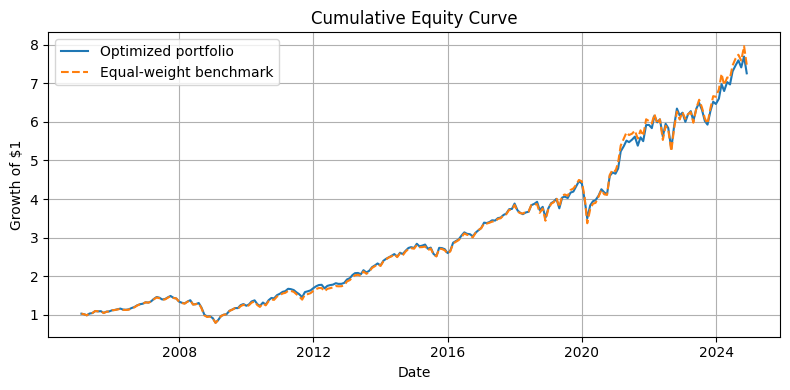

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def performance_metrics(returns, freq=12):
    returns = np.asarray(returns, dtype=float)

    if len(returns) == 0:
        return {
            "mean_ret_monthly": np.nan,
            "vol_annual": np.nan,
            "sharpe_annual": np.nan,
            "max_drawdown": np.nan,
            "cum_return": np.nan,
            "equity_curve": np.array([]),
        }

    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1) if len(returns) > 1 else np.nan

    if std_ret is not np.nan and std_ret > 0:
        sharpe = np.sqrt(freq) * mean_ret / std_ret
    else:
        sharpe = np.nan

    vol_annual = std_ret * np.sqrt(freq) if not np.isnan(std_ret) else np.nan

    equity = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_cum_ret = equity[-1] - 1.0

    return {
        "mean_ret_monthly": mean_ret,
        "vol_annual": vol_annual,
        "sharpe_annual": sharpe,
        "max_drawdown": max_dd,
        "cum_return": total_cum_ret,
        "equity_curve": equity,
    }

port_ret_arr = np.array(portfolio_returns, dtype=float)
bench_ret_arr = np.array(benchmark_returns, dtype=float)

metrics_port = performance_metrics(port_ret_arr, freq=12)
metrics_bench = performance_metrics(bench_ret_arr, freq=12)

print("Optimized portfolio:")
for k, v in metrics_port.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\nEqual-weight benchmark:")
for k, v in metrics_bench.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual rebalance dates if available
backtest_dates = [x[0] for x in weight_history]

plt.figure(figsize=(8, 4))
plt.plot(backtest_dates, metrics_port["equity_curve"], label="Optimized portfolio")
plt.plot(backtest_dates, metrics_bench["equity_curve"], label="Equal-weight benchmark", linestyle="--")
plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
dates_bt = [d for d, _, _ in weight_history]

# Collect all permnos that ever appear
all_permnos = sorted({p for _, plist, _ in weight_history for p in plist})

# Build a time-by-asset weight matrix, filling missing entries with 0
W_df = pd.DataFrame(0.0, index=dates_bt, columns=all_permnos)

for d, plist, w in weight_history:
    W_df.loc[d, plist] = w

print("Weight matrix shape:", W_df.shape)

avg_weights = W_df.mean(axis=0)

weight_summary = (
    pd.DataFrame({
        "permno": avg_weights.index,
        "avg_weight": avg_weights.values
    })
    .sort_values("avg_weight", ascending=False)
)

weight_summary.head(10)

Weight matrix shape: (239, 196)


,permno,avg_weight
78,14593,0.015682
67,13901,0.015676
20,11404,0.015662
108,17750,0.015656
141,22111,0.015655
66,13856,0.015655
11,10516,0.015653
105,17144,0.015652
101,16600,0.015651
129,20482,0.015648


In [10]:
import numpy as np
import pandas as pd

dates_bt = [d for d, _, _ in weight_history]

# Collect all permnos that ever appear
all_permnos = sorted({p for _, plist, _ in weight_history for p in plist})

# Build a full time-by-asset weight matrix, filling missing weights with 0
W_df = pd.DataFrame(0.0, index=dates_bt, columns=all_permnos)

for d, plist, w in weight_history:
    W_df.loc[d, plist] = w

W = W_df.values

print("Weight matrix shape:", W.shape)

# Equal-weight benchmark over the union of all assets
ew_full = np.ones(W.shape[1]) / W.shape[1]

# Average L1 distance from this full-sample equal-weight vector
avg_l1_dist = np.mean(np.abs(W - ew_full).sum(axis=1))
print("Average L1 distance from equal-weight:", avg_l1_dist)

# Average turnover
turnover_series = np.abs(np.diff(W, axis=0)).sum(axis=1)
print("Average turnover per rebalance:", turnover_series.mean())

Weight matrix shape: (239, 196)
Average L1 distance from equal-weight: 1.3273358714492753
Average turnover per rebalance: 0.005200708871569031


Sanity Check: Are We Really Avoiding the Equal-Weight Regime?

Before interpreting the full backtest, we verify that the optimizer responds to differences in asset quality rather than mechanically producing something close to an equal-weight portfolio. If some assets have higher estimated returns than others, the optimizer should assign them larger weights, all else equal. If it instead always returns nearly equal weights, that would suggest either an implementation error, a failure of the gradient-based optimization routine, or parameter choices that overwhelm the return signal.

To check this, we run a simple two-asset experiment using the same optimization code as in the main model. We first compute the average monthly return of each stock in the return panel and select one “good” stock with a relatively high average return and one “bad” stock with a relatively low average return. We then restrict the data to these two assets and estimate the mean vector and covariance matrix over the same rolling window used in the main backtest. Using these estimated moments, we solve the same constrained portfolio optimization problem as in the main model, imposing no short selling and full investment. For this diagnostic exercise, we temporarily set the turnover penalty to zero and do not supply previous weights, so that the optimizer selects the portfolio from scratch.

If the implementation is working correctly, the optimizer should assign more than half the weight to the better-performing stock and less than half to the worse-performing stock. This would show that the model is capable of tilting toward higher-return assets rather than defaulting to equal weights. As an additional check, we repeat the exercise on simple synthetic data in which one asset has a higher mean return while both assets share the same covariance structure. The optimizer again places greater weight on the higher-return asset.

Together, these exercises confirm that the objective and constraints are implemented correctly, that the PyTorch optimization routine is functioning as intended, and that the model is not mechanically stuck in an equal-weight regime.

In [15]:
# === More robust sanity check: choose good and bad stocks with enough overlap ===

import numpy as np
import pandas as pd

MIN_OVERLAP = ROLLING_WINDOW

# Keep only stocks with at least MIN_OVERLAP observed returns
valid_counts = ret_panel_full.notna().sum(axis=0)
eligible_cols = valid_counts[valid_counts >= MIN_OVERLAP].index

ret_candidates = ret_panel_full[eligible_cols]

# Mean return among eligible stocks
mean_ret = ret_candidates.mean(axis=0, skipna=True).dropna()

# Sort from best to worst
sorted_permnos = mean_ret.sort_values(ascending=False)

good_permno = None
bad_permno = None
ret_two = None

# Try to find a high-mean and low-mean pair with enough overlapping observations
for g in sorted_permnos.index:
    for b in sorted_permnos.index[::-1]:
        if g == b:
            continue
        temp = ret_panel_full[[g, b]].dropna()
        if len(temp) >= MIN_OVERLAP:
            good_permno = g
            bad_permno = b
            ret_two = temp.copy()
            break
    if ret_two is not None:
        break

if ret_two is None:
    raise ValueError("Could not find a good/bad stock pair with enough overlapping observations.")

print("Good stock:", good_permno, "| Mean monthly return:", float(mean_ret[good_permno]))
print("Bad stock :", bad_permno,  "| Mean monthly return:", float(mean_ret[bad_permno]))
print("Overlap length:", len(ret_two))
display(ret_two.head())

Good stock: 22623 | Mean monthly return: 0.05423232352941176
Bad stock : 15850 | Mean monthly return: -0.027062725
Overlap length: 34


permno,22623,15850
date,,
2022-03-31,0.223358,-0.024666
2022-04-29,0.052622,-0.272117
2022-05-31,0.050853,-0.004675
2022-06-30,-0.077642,-0.115385
2022-07-29,0.154384,0.051944


In [16]:
# === Sanity check: run optimizer on the chosen good/bad pair ===

import numpy as np

# Use the last ROLLING_WINDOW overlapping months
window_returns_two = ret_two.iloc[-ROLLING_WINDOW:]

# Estimate moments
mu_t_two, Sigma_t_two = estimate_moments(window_returns_two)

print("Estimated mu_t for [good, bad]:", mu_t_two)
print("Sigma_t_two:\n", Sigma_t_two)

# Temporarily remove turnover penalty
KAPPA_old = KAPPA
KAPPA = 0.0

# Fresh optimization
w_opt_two = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)

# Restore original KAPPA
KAPPA = KAPPA_old

print("\nGood stock permno:", good_permno)
print("Bad stock permno :", bad_permno)
print("Optimal weights [good, bad]:", w_opt_two)
print("Equal weight would be       :", np.array([0.5, 0.5]))
print("Sum of weights              :", w_opt_two.sum())

Estimated mu_t for [good, bad]: [ 0.04719583 -0.00219671]
Sigma_t_two:
 [[ 0.01373784 -0.00022294]
 [-0.00022294  0.01666936]]

Good stock permno: 22623
Bad stock permno : 15850
Optimal weights [good, bad]: [0.6088924 0.3911076]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0


In [17]:
# === Sanity check with lower GAMMA and no turnover penalty ===

import numpy as np

# Save original globals
GAMMA_orig = GAMMA
KAPPA_orig = KAPPA

# Relax penalties
GAMMA = 1.0
KAPPA = 0.0

print(f"Running with GAMMA={GAMMA}, KAPPA={KAPPA}")
print(f"Good stock permno: {good_permno}")
print(f"Bad stock permno : {bad_permno}")
print(f"Estimated mean returns [good, bad]: {mu_t_two}")

# Run optimizer
w_opt_low_gamma = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)

print("\nOptimal weights [good, bad]:", w_opt_low_gamma)
print("Equal weight would be       :", np.array([0.5, 0.5]))
print("Sum of weights              :", w_opt_low_gamma.sum())

# Restore globals
GAMMA = GAMMA_orig
KAPPA = KAPPA_orig
print(f"\nRestored globals: GAMMA={GAMMA}, KAPPA={KAPPA}")

Running with GAMMA=1.0, KAPPA=0.0
Good stock permno: 22623
Bad stock permno : 15850
Estimated mean returns [good, bad]: [ 0.04719583 -0.00219671]

Optimal weights [good, bad]: [0.616967 0.383033]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0

Restored globals: GAMMA=5.0, KAPPA=0.1


In [18]:
# === Sanity check: check convergence by increasing LR and STEPS ===

import numpy as np

# Save globals
GAMMA_orig = GAMMA
KAPPA_orig = KAPPA
LR_orig = LR
STEPS_orig = STEPS

# Relax penalties
GAMMA = 1.0
KAPPA = 0.0

# More aggressive optimization settings
LR = 2.0
STEPS = 2000

print(f"Running with GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")
print(f"Good stock permno: {good_permno}")
print(f"Bad stock permno : {bad_permno}")
print(f"Estimated mean returns [good, bad]: {mu_t_two}")

# Equal-weight reference
w_eq = np.array([0.5, 0.5])

def objective_value(w, mu, Sigma, gamma, kappa, w_prev=None):
    if w_prev is None:
        w_prev = np.zeros_like(w)
    exp_ret = np.dot(mu, w)
    var = float(w @ Sigma @ w)
    turnover = np.abs(w - w_prev).sum()
    return exp_ret - gamma * var - kappa * turnover

obj_eq = objective_value(w_eq, mu_t_two, Sigma_t_two, GAMMA, KAPPA, w_prev=np.zeros(2))

# Run optimizer
w_opt_fast = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)
obj_opt = objective_value(w_opt_fast, mu_t_two, Sigma_t_two, GAMMA, KAPPA, w_prev=np.zeros(2))

print("\nOptimal weights [good, bad]:", w_opt_fast)
print("Equal weight would be       :", w_eq)
print("Sum of weights              :", w_opt_fast.sum())
print("Objective at equal weight   :", obj_eq)
print("Objective at optimum        :", obj_opt)

# Restore globals
GAMMA = GAMMA_orig
KAPPA = KAPPA_orig
LR = LR_orig
STEPS = STEPS_orig
print("\nRestored globals.")

Running with GAMMA=1.0, KAPPA=0.0, LR=2.0, STEPS=2000
Good stock permno: 22623
Bad stock permno : 15850
Estimated mean returns [good, bad]: [ 0.04719583 -0.00219671]

Optimal weights [good, bad]: [0.99431026 0.00568978]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0
Objective at equal weight   : 0.015009229150319294
Objective at optimum        : 0.033334826883353076

Restored globals.


In [27]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 5.0
KAPPA = 0.005
LR = 0.1
STEPS = 1000

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Require next-month realized returns to be observed
    r_next = ret_panel_full.loc[date_next, current_permnos]
    valid_next = r_next.index[r_next.notna()]
    window_ret = window_ret[valid_next]
    r_next = r_next[valid_next]
    current_permnos = list(valid_next)

    if len(current_permnos) < 2:
        continue

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next.values))

    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=5.0, KAPPA=0.005, LR=0.1, STEPS=1000
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0096
  vol_annual: 0.1514
  sharpe_annual: 0.7626
  max_drawdown: -0.4752
  cum_return: 6.8492

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0094
  vol_annual: 0.1476
  sharpe_annual: 0.7620
  max_drawdown: -0.4664
  cum_return: 6.4788


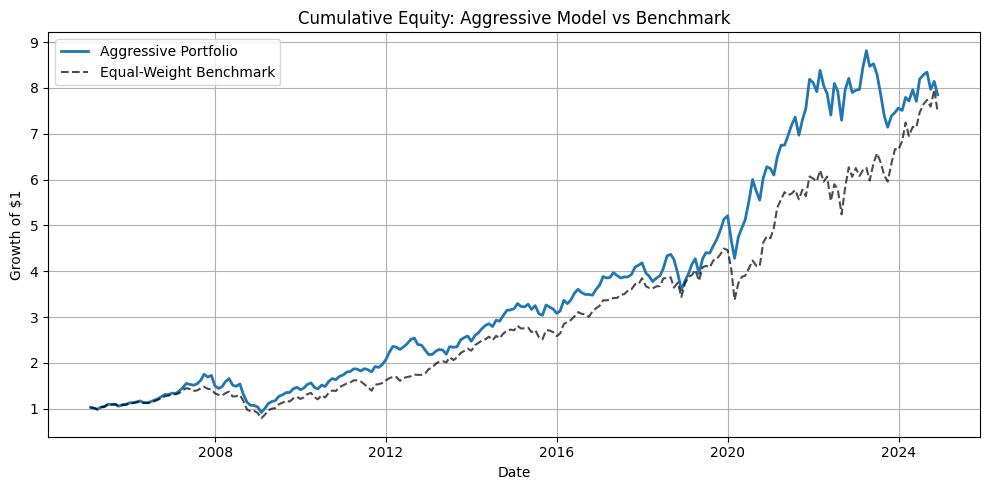

In [28]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Check if we are actually deviating from equal weights now

import numpy as np

l1_dists_agg = []
turnovers_agg = []

prev_w_dict = None

for d, plist, w in weight_history_agg:
    # Distance from month-specific equal weight
    n_t = len(plist)
    ew_t = np.ones(n_t) / n_t
    l1_dists_agg.append(np.abs(w - ew_t).sum())

    # Turnover relative to previous month, aligned on union of names
    curr_w_dict = {p: wt for p, wt in zip(plist, w)}

    if prev_w_dict is not None:
        union_names = sorted(set(prev_w_dict.keys()) | set(curr_w_dict.keys()))
        prev_vec = np.array([prev_w_dict.get(p, 0.0) for p in union_names])
        curr_vec = np.array([curr_w_dict.get(p, 0.0) for p in union_names])
        turnovers_agg.append(np.abs(curr_vec - prev_vec).sum())

    prev_w_dict = curr_w_dict

print(f"Average L1 distance from month-specific equal weight: {np.mean(l1_dists_agg):.4f}")
print(f"Average Monthly Turnover: {np.mean(turnovers_agg):.4f}")

Average L1 distance from month-specific equal weight: 0.9049
Average Monthly Turnover: 0.0289
